# **Preparación de los datos**

## Extracción

In [1]:
import pandas as pd
import numpy as np
data = pd.read_csv('TelecomX_data.csv')
data.head()

,customerid,churn,customer_gender,customer_seniorcitizen,customer_partner,customer_dependents,customer_tenure,phone_phoneservice,phone_multiplelines,internet_internetservice,...,internet_deviceprotection,internet_techsupport,internet_streamingtv,internet_streamingmovies,account_contract,account_paperlessbilling,account_paymentmethod,account_charges_monthly,account_charges_total,daily_accounts
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.796667


## Correlación de variables numéricas

In [2]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerid                 7043 non-null   str    
 1   churn                      7043 non-null   str    
 2   customer_gender            7043 non-null   str    
 3   customer_seniorcitizen     7043 non-null   int64  
 4   customer_partner           7043 non-null   str    
 5   customer_dependents        7043 non-null   str    
 6   customer_tenure            7043 non-null   int64  
 7   phone_phoneservice         7043 non-null   str    
 8   phone_multiplelines        7043 non-null   str    
 9   internet_internetservice   7043 non-null   str    
 10  internet_onlinesecurity    7043 non-null   str    
 11  internet_onlinebackup      7043 non-null   str    
 12  internet_deviceprotection  7043 non-null   str    
 13  internet_techsupport       7043 non-null   str    
 14  int

In [3]:
variables_numericas = data.select_dtypes( include = ['int64', 'float64'])
matriz_corr = variables_numericas.corr()
matriz_corr

,customer_seniorcitizen,customer_tenure,account_charges_monthly,account_charges_total,daily_accounts
customer_seniorcitizen,1.000000,0.016567,0.220173,0.103006,0.220173
customer_tenure,0.016567,1.000000,0.247900,0.826178,0.247900
account_charges_monthly,0.220173,0.247900,1.000000,0.651174,1.000000
account_charges_total,0.103006,0.826178,0.651174,1.000000,0.651174
daily_accounts,0.220173,0.247900,1.000000,0.651174,1.000000


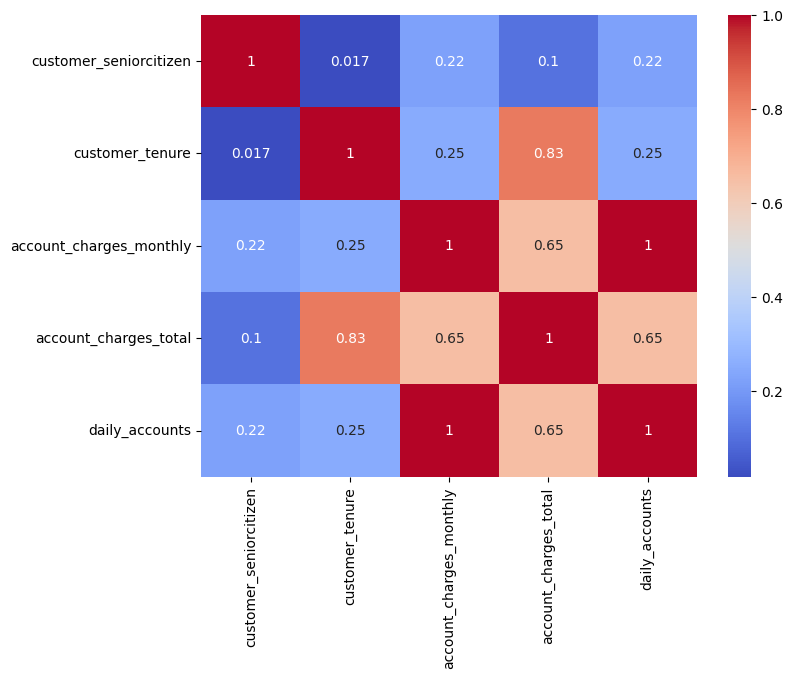

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(
    variables_numericas.corr(),
    annot=True,
    cmap='coolwarm'
)
plt.show()

## Eliminación de columnas irrelevantes

Se elimina la variable daily_accounts debido a su correlación perfecta (r=1.0) con account_charges_monthly, evitando redundancia y multicolinealidad en el modelo. También se elimina customerid puesto que sólo es un identificador del cliente. De igual manera, account_charges_total debido a su correlación (0.65) con account_charges_monthly pues se piensa trabajar regresión lineal.

In [5]:
# Elimina las columnas 'customerid', 'daily_accounts', account_charges_total'
data.drop(columns = ['customerid', 'daily_accounts', 'account_charges_total'], inplace = True)

In [6]:
data.columns

Index(['churn', 'customer_gender', 'customer_seniorcitizen',
       'customer_partner', 'customer_dependents', 'customer_tenure',
       'phone_phoneservice', 'phone_multiplelines', 'internet_internetservice',
       'internet_onlinesecurity', 'internet_onlinebackup',
       'internet_deviceprotection', 'internet_techsupport',
       'internet_streamingtv', 'internet_streamingmovies', 'account_contract',
       'account_paperlessbilling', 'account_paymentmethod',
       'account_charges_monthly'],
      dtype='str')

## Encoding

In [ ]:
# Separa variables
X = data.drop('churn', axis = 1)
y = data['churn']

In [ ]:
X

,customer_gender,customer_seniorcitizen,customer_partner,customer_dependents,customer_tenure,phone_phoneservice,phone_multiplelines,internet_internetservice,internet_onlinesecurity,internet_onlinebackup,internet_deviceprotection,internet_techsupport,internet_streamingtv,internet_streamingmovies,account_contract,account_paperlessbilling,account_paymentmethod,account_charges_monthly
0,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60
1,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90
2,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90
3,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00
4,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Female,0,No,No,13,Yes,No,DSL,Yes,No,No,Yes,No,No,One year,No,Mailed check,55.15
7039,Male,0,Yes,No,22,Yes,Yes,Fiber optic,No,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10
7040,Male,0,No,No,2,Yes,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30
7041,Male,0,Yes,Yes,67,Yes,No,DSL,Yes,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85


In [ ]:
y

0        No
1        No
2       Yes
3       Yes
4       Yes
       ... 
7038     No
7039    Yes
7040     No
7041     No
7042     No
Name: churn, Length: 7043, dtype: str

In [ ]:
# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify = y,  random_state = 5)

### Transformando las variables categóricas

In [ ]:
import sklearn 
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder

In [ ]:
data.columns

Index(['churn', 'customer_gender', 'customer_seniorcitizen',
       'customer_partner', 'customer_dependents', 'customer_tenure',
       'phone_phoneservice', 'phone_multiplelines', 'internet_internetservice',
       'internet_onlinesecurity', 'internet_onlinebackup',
       'internet_deviceprotection', 'internet_techsupport',
       'internet_streamingtv', 'internet_streamingmovies', 'account_contract',
       'account_paperlessbilling', 'account_paymentmethod',
       'account_charges_monthly'],
      dtype='str')

In [ ]:
variables_categoricas = ['customer_gender', 'customer_seniorcitizen',
       'customer_partner', 'customer_dependents',
       'phone_phoneservice', 'phone_multiplelines', 'internet_internetservice',
       'internet_onlinesecurity', 'internet_onlinebackup',
       'internet_deviceprotection', 'internet_techsupport',
       'internet_streamingtv', 'internet_streamingmovies', 'account_contract',
       'account_paperlessbilling', 'account_paymentmethod',
       ]

In [ ]:
one_hot = make_column_transformer((
    OneHotEncoder(drop = 'if_binary'),
    (variables_categoricas)
),
    remainder = 'passthrough',
    sparse_threshold=0,
    force_int_remainder_cols=False)

X_encoded = one_hot.fit_transform(X_train)

column_names = one_hot.get_feature_names_out()
X_encoded = pd.DataFrame(X_encoded, columns=column_names)
X_encoded.head()

c:\Users\andre\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\compose\_column_transformer.py:978: FutureWarning: The parameter `force_int_remainder_cols` is deprecated and will be removed in 1.9. It has no effect. Leave it to its default value to avoid this warning.
  warnings.warn(


,onehotencoder__customer_gender_Male,onehotencoder__customer_seniorcitizen_1,onehotencoder__customer_partner_Yes,onehotencoder__customer_dependents_Yes,onehotencoder__phone_phoneservice_Yes,onehotencoder__phone_multiplelines_No,onehotencoder__phone_multiplelines_No phone service,onehotencoder__phone_multiplelines_Yes,onehotencoder__internet_internetservice_DSL,onehotencoder__internet_internetservice_Fiber optic,...,onehotencoder__account_contract_Month-to-month,onehotencoder__account_contract_One year,onehotencoder__account_contract_Two year,onehotencoder__account_paperlessbilling_Yes,onehotencoder__account_paymentmethod_Bank transfer (automatic),onehotencoder__account_paymentmethod_Credit card (automatic),onehotencoder__account_paymentmethod_Electronic check,onehotencoder__account_paymentmethod_Mailed check,remainder__customer_tenure,remainder__account_charges_monthly
0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,61.0,61.45
1,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,69.0,61.45
2,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,47.0,84.95
3,0.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,71.0,109.00
4,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,12.0,43.80


### Tranformando la variable respuesta

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_train)
y

array([0, 0, 0, ..., 0, 0, 0], shape=(5282,))

## Verificación de la Proporción de Cancelación (Churn)

In [ ]:
data['churn'].value_counts()

churn
No     5174
Yes    1869
Name: count, dtype: int64

In [14]:
churn_yes = data.groupby('churn').size()['Yes'] * 100 / len(data)
print(f'Porcentaje de clientes que SÍ han cancelado el servicio: {churn_yes:.2f}%')

Porcentaje de clientes que SÍ han cancelado el servicio: 26.54%


In [15]:
churn_no = data.groupby('churn').size()['No'] * 100 / len(data)
print(f'Porcentaje de clientes que NO han cancelado el servicio: {churn_no:.2f}%')

Porcentaje de clientes que NO han cancelado el servicio: 73.46%


## Desbalanceo de clases